--- LEYENDO ARCHIVO: battery_characterization_curve.csv ---
Se han cargado 13169 puntos de medición exitosamente.

>>> CAPACIDAD FÍSICA TOTAL: 2837.29 mAh <<<

--- RECALCULO DE LÍMITES ---
Voltaje de corte establecido en: 7.0 V
Esto ocurre al 50.02% de la capacidad real.
Por tanto, tu display mostrará 0% cuando la batería real esté al 50.02%.

      CÓDIGO PARA COPIAR A ARDUINO (CORTE 7V)     
// Configuración: 0% Display = 7.0V (Corte estricto)
const float capacidadBateria = 2837;
const int numPuntos = 21;
const float tablaVoltajes[21] = {
7.81, 7.79, 7.75, 7.72, 7.69, 7.65, 7.61, 7.56, 7.51, 7.46, 7.41, 7.36, 7.31, 7.26, 7.21, 7.18, 7.13, 7.09, 7.06, 7.03, 7.00
};

Generando gráfica comparativa...


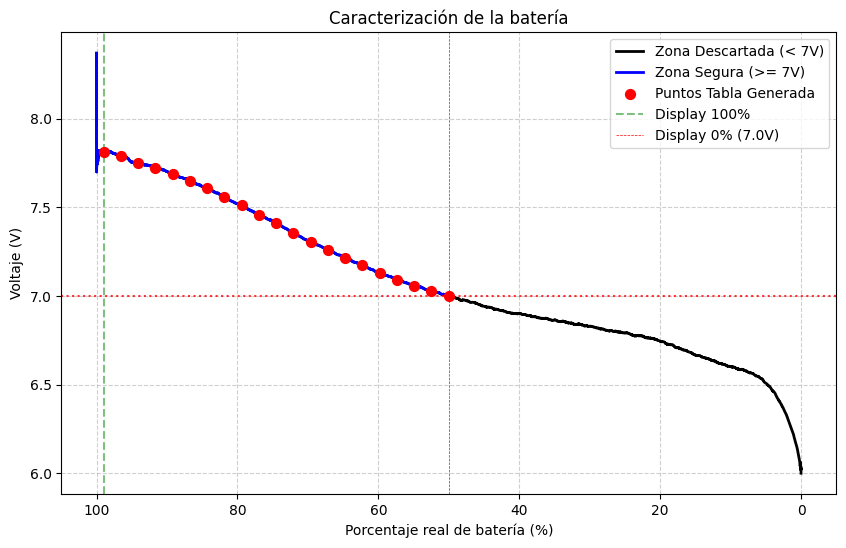

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#  CONFIGURACIÓN DE USUARIO
ARCHIVO_CSV = 'battery_characterization_curve.csv'

# LÍMITES DE SEGURIDAD
VOLTAJE_MINIMO_PLACA = 7.0
LIMITE_SUPERIOR_REAL = 99

print(f" LEYENDO ARCHIVO: {ARCHIVO_CSV} ")

try:
    # CARGA DE DATOS
    df = pd.read_csv(ARCHIVO_CSV, on_bad_lines='skip')

    # Limpieza básica
    cols = ['Voltaje_V', 'mAh_Consumidos']
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(subset=cols, inplace=True)

    print(f"Se han cargado {len(df)} puntos de medición exitosamente.")

    # CÁLCULOS
    capacidad_total_absoluta = df['mAh_Consumidos'].max()
    print(f"\n>>> CAPACIDAD FÍSICA TOTAL: {capacidad_total_absoluta:.2f} mAh <<<")

    # Cálculo  del porcentaje FÍSICO REAL (100% -> 0%)
    df['Porcentaje_Real'] = 100 - (df['mAh_Consumidos'] / capacidad_total_absoluta * 100)

    # SUAVIZADO
    window_size = 50
    df['Voltaje_Smooth'] = df['Voltaje_V'].rolling(window=window_size, center=True).mean()
    df['Voltaje_Smooth'] = df['Voltaje_Smooth'].fillna(df['Voltaje_V'])

    # Se  filtra el DataFrame para ignorar todo lo que esté por debajo de 7.0V
    df_valid = df[df['Voltaje_Smooth'] >= VOLTAJE_MINIMO_PLACA].copy()

    if df_valid.empty:
        raise ValueError(f"ERROR: Todos los voltajes del archivo son menores a {VOLTAJE_MINIMO_PLACA}V.")

    # Cálculo dinámico del Límite Inferior Real
    LIMITE_INFERIOR_REAL = df_valid['Porcentaje_Real'].min()

    print(f"\n CÁLCULO DE LÍMITES ")
    print(f"Voltaje de corte establecido en: {VOLTAJE_MINIMO_PLACA} V")
    print(f"Esto ocurre al {LIMITE_INFERIOR_REAL:.2f}% de la capacidad real.")
    print(f"Por tanto, tu display mostrará 0% cuando la batería real esté al {LIMITE_INFERIOR_REAL:.2f}%.")

    # GENERACIÓN DE LA TABLA C++
    pasos_display = list(range(100, -1, -5))
    tabla_voltajes = []
    puntos_grafica_x = []

    print("\n" + "="*50)
    print("      CÓDIGO PARA COPIAR A ARDUINO ")
    print("="*50)
    print(f"// Configuración: 0% Display = {VOLTAJE_MINIMO_PLACA}V (Corte estricto)")
    print(f"const float capacidadBateria = {capacidad_total_absoluta:.0f};")
    print("const int numPuntos = 21;")
    print("const float tablaVoltajes[21] = {")

    str_valores = ""

    for p_display in pasos_display:
        rango_seguro = LIMITE_SUPERIOR_REAL - LIMITE_INFERIOR_REAL
        p_real_objetivo = LIMITE_INFERIOR_REAL + (p_display / 100.0 * rango_seguro)

        # Se busca el voltaje en el DF completo (o valido) más cercano a ese porcentaje
        idx = (df_valid['Porcentaje_Real'] - p_real_objetivo).abs().idxmin()
        voltaje_val = df_valid.loc[idx, 'Voltaje_Smooth']

        if voltaje_val < VOLTAJE_MINIMO_PLACA:
            voltaje_val = VOLTAJE_MINIMO_PLACA

        tabla_voltajes.append(voltaje_val)
        puntos_grafica_x.append(p_real_objetivo)

        str_valores += f"{voltaje_val:.2f}, "

    print(str_valores.rstrip(", "))
    print("};")
    print("="*50)

    # GRÁFICA DE VERIFICACIÓN
    plt.figure(figsize=(10, 6))

    # Curva completa original
    plt.plot(df['Porcentaje_Real'], df['Voltaje_Smooth'], color='black', linewidth=2, label='Zona Descartada (< 7V)')

    # Zona Segura
    plt.plot(df_valid['Porcentaje_Real'], df_valid['Voltaje_Smooth'], color='blue', linewidth=2, label='Zona Segura (>= 7V)')

    # Puntos de la tabla
    plt.scatter(puntos_grafica_x, tabla_voltajes, color='red', zorder=5, s=50, label='Puntos Tabla Generada')

    # Líneas de límite
    plt.axvline(x=LIMITE_SUPERIOR_REAL, color='green', linestyle='--', alpha=0.5, label='Display 100%')
    plt.axvline(x=LIMITE_INFERIOR_REAL, color='red', linestyle='--', linewidth=0.5, label=f'Display 0% ({VOLTAJE_MINIMO_PLACA}V)')

    # Línea horizontal de 7V para confirmar visualmente
    plt.axhline(y=VOLTAJE_MINIMO_PLACA, color='red', linestyle=':', alpha=0.8)

    plt.title(f'Caracterización de la batería')
    plt.xlabel('Porcentaje real de batería (%)')
    plt.ylabel('Voltaje (V)')
    plt.gca().invert_xaxis()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    print("\nGenerando gráfica comparativa...")
    plt.show()

except FileNotFoundError:
    print(f"ERROR: No se encuentra el archivo '{ARCHIVO_CSV}'.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")